In [1]:
from pathlib import Path
import os

# Find project root by folder name
cwd = Path(os.getcwd())

while cwd.name != "dfsc":
    cwd = cwd.parent

os.chdir(cwd)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\Devanshi\dfsc


In [2]:
# ============================================================
# notebooks/04_xgboost_forecasting.ipynb
# ============================================================

import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")
# In any model file or notebook
from src.constants import ACCENT, ACCENT2, ACCENT3, ACCENT4, PLOT_STYLE

# Apply style globally at the top of any notebook
import matplotlib.pyplot as plt
plt.rcParams.update(PLOT_STYLE)
from src.models.xgboost_model import (
    encode_categoricals, FEATURE_COLS, TARGET_COL,
    train_xgboost_model, predict_and_evaluate,
    plot_feature_importance, plot_xgb_vs_actual
)
from src.models.prophet_model import calculate_metrics
from src.config import TRAIN_END_DATE, FIGURES_DIR

ACCENT  = "#00d4ff"
ACCENT2 = "#ff6b6b"
ACCENT3 = "#51cf66"
ACCENT4 = "#ffd43b"

# ---- Load feature-engineered data ----
train_df = pd.read_parquet("data/processed/train_features.parquet")
test_df  = pd.read_parquet("data/processed/test_features.parquet")

# ---- Encode categorical columns ----
train_df = encode_categoricals(train_df)
test_df  = encode_categoricals(test_df)

# ---- Verify all feature columns exist ----
missing_cols = [c for c in FEATURE_COLS if c not in train_df.columns]
if missing_cols:
    print(f"WARNING — Missing columns: {missing_cols}")
else:
    print(f"All {len(FEATURE_COLS)} feature columns present. Ready to train.")

print(f"\nTraining set  : {len(train_df):,} rows across "
      f"{train_df['Store'].nunique()} stores")
print(f"Validation set: {len(test_df):,} rows")

All 31 feature columns present. Ready to train.

Training set  : 617,140 rows across 1115 stores
Validation set: 196,032 rows


In [3]:
# ---- Train the global XGBoost model ----
print("Training XGBoost global model...")
print("(This trains ONE model on all stores simultaneously)\n")

xgb_model = train_xgboost_model(train_df, test_df)
print("\nTraining complete.")

Training XGBoost global model...
(This trains ONE model on all stores simultaneously)

[0]	validation_0-rmse:0.39786
[100]	validation_0-rmse:0.14754
[200]	validation_0-rmse:0.13918
[300]	validation_0-rmse:0.13683
[400]	validation_0-rmse:0.13526
[499]	validation_0-rmse:0.13438
Best iteration: 497

Training complete.


In [4]:
# ---- Generate predictions and evaluate ----
results_df, overall_metrics = predict_and_evaluate(xgb_model, test_df)

print("=== XGBOOST OVERALL ACCURACY (ALL STORES) ===")
for metric, value in overall_metrics.items():
    print(f"  {metric}: {value}")

# ---- Accuracy by ABC class ----
print("\n=== XGBOOST ACCURACY BY ABC CLASS ===")
for cls in ["A", "B", "C"]:
    cls_data = results_df[results_df["ABC_Class"] == cls]
    cls_metrics = calculate_metrics(cls_data["Sales"], cls_data["Predicted_Sales"])
    n_stores = cls_data["Store"].nunique()
    print(f"  Class {cls} ({n_stores} stores): "
          f"MAPE={cls_metrics['MAPE']:.1f}% | WAPE={cls_metrics['WAPE']:.1f}%")

# ---- Accuracy by XYZ class ----
print("\n=== XGBOOST ACCURACY BY XYZ CLASS ===")
for cls in ["X", "Y", "Z"]:
    cls_data = results_df[results_df["XYZ_Class"] == cls]
    if len(cls_data) == 0:
        continue
    cls_metrics = calculate_metrics(cls_data["Sales"], cls_data["Predicted_Sales"])
    n_stores = cls_data["Store"].nunique()
    print(f"  Class {cls} ({n_stores} stores): "
          f"MAPE={cls_metrics['MAPE']:.1f}% | WAPE={cls_metrics['WAPE']:.1f}%")

=== XGBOOST OVERALL ACCURACY (ALL STORES) ===
  MAPE: 9.63
  MAE: 645.56
  RMSE: 931.04
  WAPE: 9.11

=== XGBOOST ACCURACY BY ABC CLASS ===
  Class A (775 stores): MAPE=9.4% | WAPE=8.9%
  Class B (235 stores): MAPE=10.0% | WAPE=9.6%
  Class C (105 stores): MAPE=10.7% | WAPE=10.2%

=== XGBOOST ACCURACY BY XYZ CLASS ===
  Class X (83 stores): MAPE=8.1% | WAPE=7.8%
  Class Y (1030 stores): MAPE=9.7% | WAPE=9.2%
  Class Z (2 stores): MAPE=16.2% | WAPE=14.7%


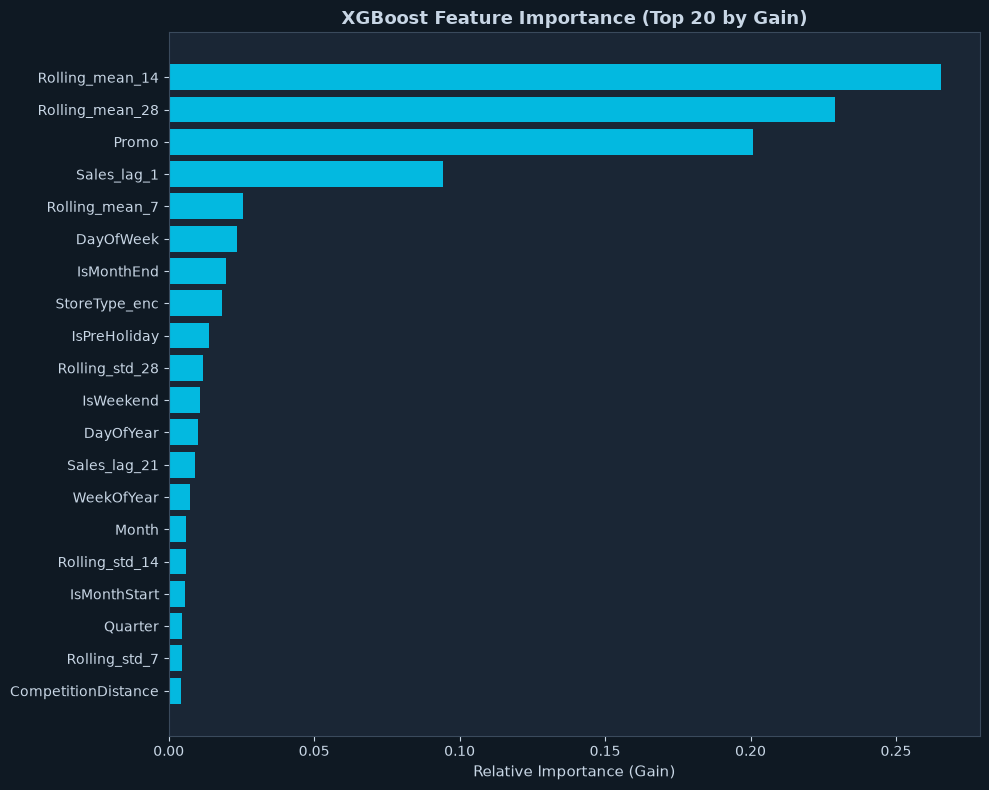


How to interpret feature importance in interview:
-------------------------------------------------
If Sales_lag_7 is the #1 feature: 'The model's single most powerful 
predictor is what happened exactly one week ago — confirming that 
weekly seasonality is the dominant demand driver. This means 
replenishment cycles should align with weekly demand rhythms.'

If Promo is in the top 3: 'Promotional activity is one of the 
strongest demand signals. This confirms that supply chain and 
commercial teams must share promotional calendars at least 4 weeks 
in advance — the lead time needed to pre-position inventory.'

If Rolling_mean_28 ranks highly: 'Recent demand level (4-week 
rolling average) significantly improves accuracy — this is equivalent 
to a planner saying the current period's demand baseline matters as 
much as the seasonal calendar pattern.'



In [5]:
# ---- Feature importance ----
plot_feature_importance(xgb_model, top_n=20)

print("""
How to interpret feature importance in interview:
-------------------------------------------------
If Sales_lag_7 is the #1 feature: 'The model's single most powerful 
predictor is what happened exactly one week ago — confirming that 
weekly seasonality is the dominant demand driver. This means 
replenishment cycles should align with weekly demand rhythms.'

If Promo is in the top 3: 'Promotional activity is one of the 
strongest demand signals. This confirms that supply chain and 
commercial teams must share promotional calendars at least 4 weeks 
in advance — the lead time needed to pre-position inventory.'

If Rolling_mean_28 ranks highly: 'Recent demand level (4-week 
rolling average) significantly improves accuracy — this is equivalent 
to a planner saying the current period's demand baseline matters as 
much as the seasonal calendar pattern.'
""")

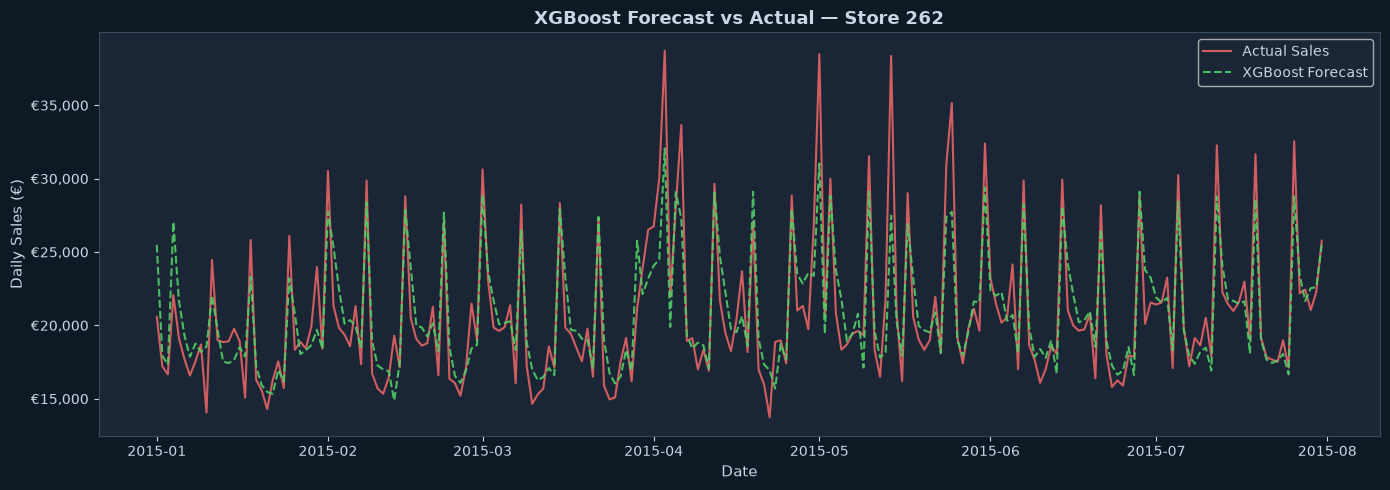

In [6]:
# ---- Visual: actual vs predicted for a representative store ----
top_store = (results_df.groupby("Store")["Sales"].sum().idxmax())
plot_xgb_vs_actual(results_df, top_store, TRAIN_END_DATE)

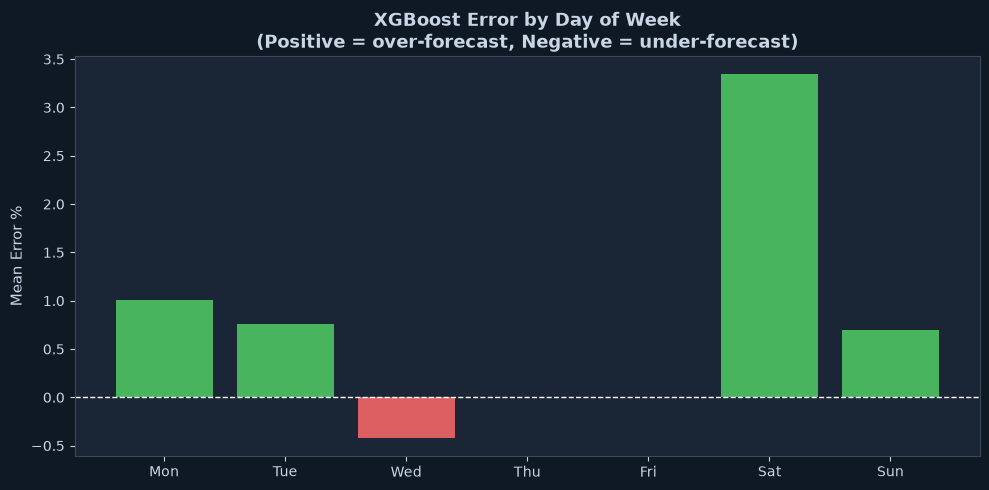


SYSTEMATIC ERRORS — WHAT THEY MEAN:
------------------------------------
If Saturday shows consistent NEGATIVE error (we under-forecast Saturday):
→ The model underestimates weekend demand spikes. 
→ Action: add interaction features between IsWeekend and Promo, 
  or add a store-specific weekend multiplier.

If errors are random across all days:
→ The model has captured all systematic patterns.
→ Remaining error is genuine demand uncertainty — this is what 
  safety stock is designed to absorb.



In [7]:
# ---- Error analysis by day of week ----
# Are our forecast errors random, or do they spike on specific days?
# Systematic errors point to something the model is missing.

results_df["Error_pct"] = ((results_df["Predicted_Sales"] - results_df["Sales"])
                            / results_df["Sales"] * 100)
results_df["DayOfWeek"] = pd.to_datetime(results_df["Date"]).dt.dayofweek

dow_error = results_df.groupby("DayOfWeek")["Error_pct"].mean()
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT3 if v >= 0 else ACCENT2 for v in dow_error.values]
ax.bar(dow_labels[:len(dow_error)], dow_error.values,
       color=colors, alpha=0.85, edgecolor="none")
ax.axhline(0, color="white", linewidth=1, linestyle="--")
ax.set_title("XGBoost Error by Day of Week\n"
             "(Positive = over-forecast, Negative = under-forecast)",
             fontweight="bold")
ax.set_ylabel("Mean Error %")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/forecasts/xgb_error_by_dow.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print("""
SYSTEMATIC ERRORS — WHAT THEY MEAN:
------------------------------------
If Saturday shows consistent NEGATIVE error (we under-forecast Saturday):
→ The model underestimates weekend demand spikes. 
→ Action: add interaction features between IsWeekend and Promo, 
  or add a store-specific weekend multiplier.

If errors are random across all days:
→ The model has captured all systematic patterns.
→ Remaining error is genuine demand uncertainty — this is what 
  safety stock is designed to absorb.
""")

In [8]:
# ---- Save XGBoost results for Power BI and Phase 8 comparison ----
results_df.to_csv("outputs/forecasts/xgboost_forecasts.csv", index=False)

# Export for Power BI
powerbi_export = results_df[["Store","Date","Sales","Predicted_Sales",
                               "ABC_Class","XYZ_Class"]].copy()
powerbi_export.columns = ["Store","Date","Actual","XGB_Forecast",
                           "ABC_Class","XYZ_Class"]
powerbi_export.to_csv("outputs/powerbi/pb_xgb_forecast.csv", index=False)
print("XGBoost results saved. Ready for Phase 8 model comparison.")

XGBoost results saved. Ready for Phase 8 model comparison.
